---
title: "The coupling pattern"
short_title: "00 · Coupling pattern"
subtitle: "Split, condition, transform — why a coupling layer has a triangular Jacobian, a free log-det, and an analytic inverse with no network inversion"
description: >
  Coupling is the expressive engine of modern Gaussianization. A coupling layer
  leaves half the coordinates unchanged and transforms the other half with a
  bijector whose parameters are predicted by a neural conditioner from the
  unchanged half. This notebook builds the pattern from scratch with gauss_flows,
  shows the Jacobian is triangular (so the log-det is the cheap sum of the active
  half's scales), and shows the inverse never inverts the network.
---

(sec-nb-cpl-00)=
# 00 — The coupling pattern

Part 4 used coupling flows as a black box and saw they are more expressive per
parameter than diagonal marginals. Part 5 opens the box. The **coupling layer**
(Dinh et al., RealNVP {cite}`dinh2017realnvp`) is a deceptively simple idea with
three remarkable properties. Split the coordinates into two halves $x = (x_A,
x_B)$ via a mask, then

$$
z_A = x_A, \qquad z_B = T_{\theta(x_A)}(x_B),
$$

where $T$ is any 1-D bijector and its parameters $\theta = c_\phi(x_A)$ come from a
**conditioner** network reading the *unchanged* half. The passive half $x_A$ is
copied through; only $x_B$ is transformed, and its transform is *conditioned on*
$x_A$. From this one move follow:

1. a **triangular Jacobian**, so the log-determinant is a cheap sum;
2. an **analytic inverse** that never inverts the conditioner network;
3. **arbitrary expressiveness** — $c_\phi$ can be any network, $T$ any bijector.

**What you will see**

- A coupling layer (`gf.AffineCoupling`) splitting, conditioning, and transforming.
- The **triangular Jacobian** and why $\log|\det| = \sum \log|s|$ over the active
  half is *free*.
- The **inverse** round-tripping at machine precision with no network inversion.
- Swapping the bijector $T$ (affine → mixture-CDF) — same pattern, more power.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

import gauss_flows as gf
from _style import GAUSS_KW, style_ax

jax.config.update("jax_enable_x64", True)

## The coupling layer at a glance

The whole mechanism in one picture: the **mask** splits the input into a passive
half $x_A$ and an active half $x_B$. The passive half is **copied** straight to the
output ($z_A = x_A$) *and* fed to a **conditioner** network that emits the
bijector's parameters $\theta = c_\phi(x_A)$. The active half is then transformed by
the **bijector** $T_\theta$ ($z_B = T_\theta(x_B)$). Because the conditioner only
sees the copied half, the Jacobian is triangular and the log-det is the cheap sum
over the active half — everything below makes this concrete.

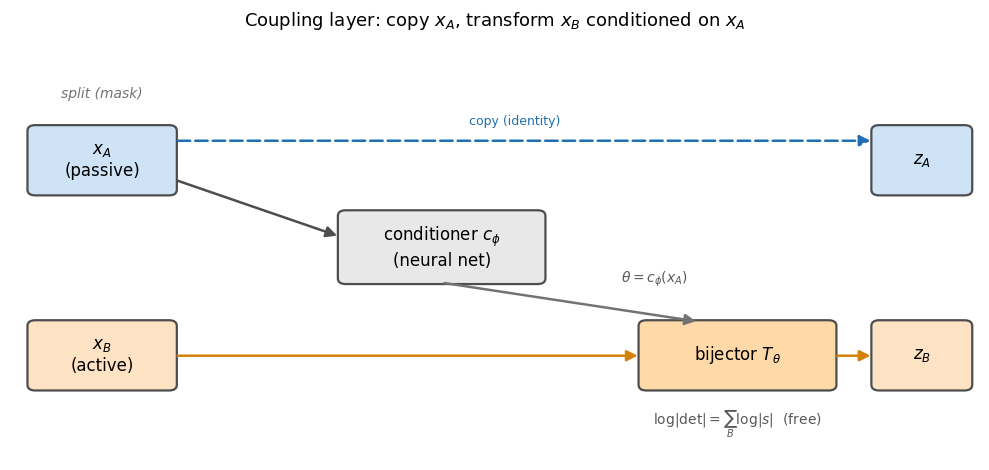

In [2]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


def _box(ax, x, y, w, h, text, fc, fs=12):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                                fc=fc, ec="0.3", lw=1.6))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs)


def _arrow(ax, p0, p1, color="0.3", lw=1.8, ls="-"):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=16,
                                 lw=lw, color=color, ls=ls))


fig, ax = plt.subplots(figsize=(10, 4.8))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off")
_box(ax, 0.2, 3.75, 1.5, 0.95, r"$x_A$" + "\n(passive)", "#cfe3f7")
_box(ax, 0.2, 1.0, 1.5, 0.95, r"$x_B$" + "\n(active)", "#fde2c4")
_box(ax, 3.4, 2.5, 2.1, 1.0, r"conditioner $c_\phi$" + "\n(neural net)", "#e8e8e8")
_box(ax, 6.5, 1.0, 2.0, 0.95, r"bijector $T_\theta$", "#ffd9a8")
_box(ax, 8.9, 3.75, 1.0, 0.95, r"$z_A$", "#cfe3f7")
_box(ax, 8.9, 1.0, 1.0, 0.95, r"$z_B$", "#fde2c4")
ax.text(0.95, 5.1, "split (mask)", ha="center", fontsize=10, style="italic", color="0.45")
_arrow(ax, (1.7, 4.5), (8.9, 4.5), color="#1f6fb2", ls=(0, (5, 2)))         # copy
ax.text(5.2, 4.72, "copy (identity)", ha="center", fontsize=9, color="#1f6fb2")
_arrow(ax, (1.7, 3.95), (3.4, 3.15))                                       # x_A -> conditioner
_arrow(ax, (4.45, 2.5), (7.1, 1.95), color="0.45")                         # theta -> bijector
ax.text(6.3, 2.5, r"$\theta=c_\phi(x_A)$", fontsize=10, color="0.35")
_arrow(ax, (1.7, 1.47), (6.5, 1.47), color="#d4820a")                      # x_B -> bijector
_arrow(ax, (8.5, 1.47), (8.9, 1.47), color="#d4820a")                      # bijector -> z_B
ax.text(7.5, 0.5, r"$\log|\det|=\sum_{B}\log|s|$  (free)", ha="center", fontsize=10, color="0.35")
ax.set_title(r"Coupling layer: copy $x_A$, transform $x_B$ conditioned on $x_A$", fontsize=13)
fig.tight_layout()

## 1. Split, condition, transform

`gf.AffineCoupling` is the canonical example: the active half is transformed by an
**affine** map $z_B = s(x_A)\odot x_B + t(x_A)$, with the log-scale $s$ and shift
$t$ predicted by an MLP from the passive half. We build one on a 4-D event and see
exactly which coordinates it touches.

In [3]:
d = 4
coupling = gf.AffineCoupling(jr.key(0), shape=(d,), nn_width=32, nn_depth=2)

x = jr.normal(jr.key(1), (d,))
z, log_det = coupling.transform_and_log_det(x)
unchanged = [int(i) for i in np.where(np.abs(np.asarray(z - x)) < 1e-9)[0]]
print(f"input  x = {np.round(np.asarray(x), 3)}")
print(f"output z = {np.round(np.asarray(z), 3)}")
print(f"passive half (unchanged): coords {unchanged}")
print(f"active half (transformed): coords {[i for i in range(d) if i not in unchanged]}")

input  x = [-1.184 -0.116  0.173  0.957]
output z = [-1.184 -0.116  0.363  0.679]
passive half (unchanged): coords [0, 1]
active half (transformed): coords [2, 3]


The first two coordinates pass straight through; the last two are rescaled and
shifted by amounts the conditioner computed *from the first two*. That conditioning
is what lets a coupling model dependence — the transform of $x_B$ bends with $x_A$
— while keeping everything else exactly invertible.

## 2. The triangular Jacobian → a free log-det

Here is the magic. Because $z_A = x_A$ does not depend on $x_B$, and $z_B$ depends
on $x_B$ only through the (elementwise) bijector $T$, the Jacobian
$\partial z/\partial x$ is **block-triangular**:

$$
J = \begin{pmatrix} I & 0 \\ \partial z_B/\partial x_A & \mathrm{diag}(s) \end{pmatrix}.
$$

A triangular matrix's determinant is the product of its diagonal, so
$\log|\det J| = \sum_{i\in B}\log|s_i|$ — just the active half's log-scales, with
**no Jacobian ever formed**. We confirm against an autodiff Jacobian.

Jacobian:
[[ 1.     0.     0.     0.   ]
 [ 0.     1.     0.     0.   ]
 [-0.08  -0.036  1.031  0.   ]
 [ 0.02   0.027  0.     0.963]]

strictly-upper-triangular part max |·| = 0.0e+00  (zero → triangular)
log|det J|  (from autodiff Jacobian) = -0.00768
sum of log|diagonal|                 = -0.00768
coupling.transform_and_log_det       = -0.00768   (all equal)


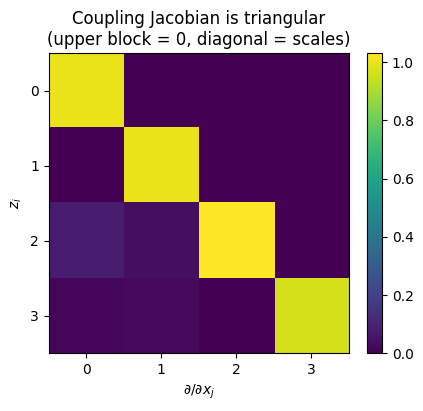

In [4]:
J = jax.jacfwd(coupling.transform)(x)
print("Jacobian:")
print(np.round(np.asarray(J), 3))
print(f"\nstrictly-upper-triangular part max |·| = {float(jnp.abs(jnp.triu(J, 1)).max()):.1e}  (zero → triangular)")
print(f"log|det J|  (from autodiff Jacobian) = {float(jnp.linalg.slogdet(J)[1]):+.5f}")
print(f"sum of log|diagonal|                 = {float(jnp.sum(jnp.log(jnp.abs(jnp.diag(J))))):+.5f}")
print(f"coupling.transform_and_log_det       = {float(log_det):+.5f}   (all equal)")

fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(np.abs(np.asarray(J)), cmap="viridis")
ax.set(title="Coupling Jacobian is triangular\n(upper block = 0, diagonal = scales)",
       xticks=range(d), yticks=range(d), xlabel="$\\partial / \\partial x_j$", ylabel="$z_i$")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()

The strictly-upper-triangular block is exactly zero, the passive diagonal is $1$,
and the three estimates of the log-det agree to machine precision. This is the
whole reason coupling flows scale: a general invertible map needs an $O(d^3)$
determinant, but a coupling layer's is an $O(d)$ sum — and the conditioner can be
arbitrarily expressive without changing that, because it only fills the
*off-diagonal* block, which the determinant ignores.

## 3. The inverse never inverts the network

Inverting a coupling is just as cheap, and this is the second surprise. Given
$z = (z_A, z_B)$:

$$
x_A = z_A, \qquad \theta = c_\phi(z_A)\ (= c_\phi(x_A)), \qquad x_B = T^{-1}_\theta(z_B).
$$

Because the conditioner reads the *unchanged* half, we recover $x_A = z_A$ for
free, recompute the **same** parameters $\theta$ with a forward pass, and invert
only the simple bijector $T$. The conditioner network $c_\phi$ — which may be huge
— is never inverted. We round-trip to confirm.

In [5]:
x_batch = jr.normal(jr.key(2), (2000, d))
z_batch = jax.vmap(coupling.transform)(x_batch)
x_rec = jax.vmap(coupling.inverse)(z_batch)
print(f"round-trip max error = {float(jnp.abs(x_batch - x_rec).max()):.2e}  (no network inversion)")

# log-det of inverse is the negative of the forward, also free
_, ld_fwd = coupling.transform_and_log_det(x)
_, ld_inv = coupling.inverse_and_log_det(z)
print(f"forward log_det = {float(ld_fwd):+.5f}, inverse log_det = {float(ld_inv):+.5f} "
      f"(sum = {float(ld_fwd + ld_inv):.1e})")

round-trip max error = 4.44e-16  (no network inversion)
forward log_det = -0.00768, inverse log_det = +0.00768 (sum = 0.0e+00)


Machine-precision round-trip, and the inverse log-det is exactly the negative of
the forward — both obtained by a *forward* evaluation of the conditioner. This
asymmetry-free invertibility is why coupling flows give fast sampling **and** fast
density, unlike autoregressive flows where one direction is sequential.

## 4. The bijector is swappable — affine → mixture-CDF

Nothing above used the affine form of $T$ beyond "elementwise and invertible". Swap
$T$ for a more expressive monotone bijector and the pattern — triangular Jacobian,
free log-det, analytic inverse — is unchanged. `gauss_flows` ships a menu;
`MixtureGaussianCDFCoupling` uses the Gaussian-mixture CDF of Part 1 as $T$. We
check it has the same structural properties.

In [6]:
mix = gf.MixtureGaussianCDFCoupling(jr.key(0), shape=(d,), n_components=8,
                                    nn_width=32, nn_depth=2)
xm = jr.normal(jr.key(3), (d,))
zm, ldm = mix.transform_and_log_det(xm)
Jm = jax.jacfwd(mix.transform)(xm)
xm_rec = mix.inverse(zm)
print("MixtureGaussianCDFCoupling:")
print(f"  triangular?  upper |·| max = {float(jnp.abs(jnp.triu(Jm, 1)).max()):.1e}")
print(f"  log-det matches diagonal-sum? "
      f"{bool(jnp.allclose(ldm, jnp.sum(jnp.log(jnp.abs(jnp.diag(Jm))))))}")
print(f"  round-trip = {float(jnp.abs(xm - xm_rec).max()):.1e}")
print("  -> same coupling contract, a more expressive transform")

MixtureGaussianCDFCoupling:
  triangular?  upper |·| max = 0.0e+00
  log-det matches diagonal-sum? True
  round-trip = 3.7e-07
  -> same coupling contract, a more expressive transform


Identical structure, richer $T$ — the bijector and the conditioner are independent
choices, which is exactly why the next two notebooks can tour them separately.

## Recap

| property | why | cost |
|---|---|---|
| split $x=(x_A,x_B)$, $z_B = T_{\theta(x_A)}(x_B)$ | conditioner reads the unchanged half | — |
| triangular Jacobian | $z_A$ ⟂ $x_B$; $z_B$ elementwise in $x_B$ | $\log\lvert\det\rvert=\sum_{B}\log\lvert s\rvert$, $O(d)$ |
| analytic inverse | recompute $\theta=c_\phi(z_A)$, invert only $T$ | **no network inversion** |
| swappable bijector $T$ | structure independent of $T$'s form | affine → mixture-CDF → spline |

A coupling layer transforms only half its inputs, so a single layer is not a full
bijector of all coordinates — you **alternate the mask** (Part 5
[03 — mask design](03_mask_design.ipynb)) so every coordinate is both transformed
and used as context.

**Next up.** The triangular trick works for *any* monotone $T$.
[01 — Bijector menu](01_bijector_menu.ipynb) tours the choices `gauss_flows`
offers — affine, mixture-CDF, deep-sigmoid, rational-quadratic spline — and what
each buys in expressiveness.